In [9]:
import pickle
import numpy as np
from itertools import permutations
from scipy.stats import truncnorm
from scipy.spatial.distance import cdist
import xgboost as xgb
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

np.random.seed(2026)


# Define median-based ensemble of surrogates
class medClassifier:
    def __init__(self, classifiers=None):
        self.classifiers = classifiers

    def predict(self, X):
        self.predictions_ = []
        for classifier in self.classifiers:
            try:
                self.predictions_.append(classifier.predict(X))
            except:
                X_dmatrix = xgb.DMatrix(X)
                self.predictions_.append(classifier.predict(X_dmatrix))

        med1 = np.median(self.predictions_, axis=0)
        mean1 = np.mean(self.predictions_, axis=0)
        # out = med1 + np.random.rand() * np.abs(med1 - mean1)
        out = med1
        return out


# Main wind farm problem generator
class WindFarmProblem:
    def __init__(self,
                 ensemble_file="Ensemble.pkl",   # model used for obj1
                 rotor_diameter=126,
                 farm_length=333.33 * 5,
                 n_turbines=5,
                 nr_birds=1000,
                 bird_mean=-25000,
                 x_sigma=5,                      # controls bird distribution
                 n_fields=5,                     # number of oil/gas fields OR list of coordinates
                 seed=2026):                     # random seed

        self.seed = seed
        self.rng_fields = np.random.default_rng(seed)
        self.rng_plot = np.random.default_rng(seed + 1)

        self.rotor_diameter = rotor_diameter
        self.farm_length = farm_length
        self.n_turbines = n_turbines
        self.nr_birds = nr_birds
        self.bird_mean = bird_mean
        self.x_sigma = x_sigma

        # Generate oil fields
        self.fields = self._generate_oil_fields(n_fields)
        self.n_fields = len(self.fields)

        # Load ensemble surrogate model
        with open(ensemble_file, "rb") as file:
            self.ensemble = pickle.load(file)

    # Turn [x1, x2,..., y1, y2,...] into [[x1,y1], [x2,y2], ...]
    def _to_coords(self, x):
        x = np.asarray(x, dtype=float)
        if len(x) != 2 * self.n_turbines:
            raise ValueError(
                f"x must have length {2 * self.n_turbines}, got {len(x)}"
            )

        xs = x[:self.n_turbines]
        ys = x[self.n_turbines:]
        coords = np.column_stack((xs, ys))
        return coords

    # Validate hub coordinate
    def _validate_hub(self, hub):
        hub = np.asarray(hub, dtype=float).reshape(-1)
        if hub.shape[0] != 2:
            raise ValueError("hub must be a 2D coordinate like [hub_x, hub_y].")
        return hub

    # Validate field list
    def _validate_field_list(self, field_list):
        """
        field_list format:
        [
            (xmin, xmax, ymin, ymax),
            ...
        ]
        """
        if len(field_list) > 5:
            raise ValueError("At most 5 oil fields are allowed.")

        validated = []
        for i, field in enumerate(field_list):
            if len(field) != 4:
                raise ValueError(f"Field {i} must have 4 values: (xmin, xmax, ymin, ymax).")

            xmin, xmax, ymin, ymax = map(float, field)

            if not (0 <= xmin < xmax <= 1):
                raise ValueError(
                    f"Field {i} has invalid x-range: require 0 <= xmin < xmax <= 1, got {(xmin, xmax)}"
                )
            if not (0 <= ymin < ymax <= 1):
                raise ValueError(
                    f"Field {i} has invalid y-range: require 0 <= ymin < ymax <= 1, got {(ymin, ymax)}"
                )

            validated.append((xmin, xmax, ymin, ymax))

        return validated

    # Generate random oil fields OR use provided oil field list
    def _generate_oil_fields(self, n_fields):
        # Case 1: n_fields is an integer -> random generation
        if isinstance(n_fields, int):
            fields = []
            n_fields = min(n_fields, 5)

            for _ in range(n_fields):
                width = self.rng_fields.uniform(0.05, 0.5)
                height = self.rng_fields.uniform(0.05, 0.5)

                xmin = self.rng_fields.uniform(0, 1 - width)
                ymin = self.rng_fields.uniform(0, 1 - height)

                xmax = xmin + width
                ymax = ymin + height

                fields.append((xmin, xmax, ymin, ymax))

            return fields

        # Case 2: n_fields is a list/tuple/ndarray of coordinates
        elif isinstance(n_fields, (list, tuple, np.ndarray)):
            return self._validate_field_list(list(n_fields))

        else:
            raise TypeError(
                "n_fields must be either an int or a list of field coordinates "
                "[(xmin, xmax, ymin, ymax), ...]"
            )

    # Objective 1: use ensemble surrogate to predict
    def objective1(self, x):
        x = np.array([x], dtype=float)
        pred = self.ensemble.predict(x)
        return pred[0]

    # Objective 2: calculate the percentage of birds that are too close
    def objective2(self, x):
        coords = self._to_coords(x)

        bird_std = 25000 / self.x_sigma
        birds = truncnorm.rvs(
            self.x_sigma,
            self.x_sigma + self.farm_length / bird_std,
            loc=self.bird_mean,
            scale=bird_std,
            size=self.nr_birds,
            random_state=2026
        )

        leftmost = np.min(coords[:, 0]) * self.farm_length
        threshold = leftmost - self.rotor_diameter
        close_birds = np.sum(birds >= threshold) / self.nr_birds
        return close_birds

    # Objective 3: strictly non-branching cable layout
    # Automatically search for the shortest chain:
    # hub -> turbine_a -> turbine_b -> ... -> turbine_n
    def objective3(self, x, hub):
        coords = self._to_coords(x)
        hub = self._validate_hub(hub)

        best_length = np.inf
        best_perm = None

        # enumerate all turbine visiting orders
        for perm in permutations(range(self.n_turbines)):
            total = 0.0

            # hub -> first turbine
            total += np.linalg.norm(coords[perm[0]] - hub)

            # turbine_i -> turbine_{i+1}
            for i in range(len(perm) - 1):
                total += np.linalg.norm(coords[perm[i + 1]] - coords[perm[i]])

            if total < best_length:
                best_length = total
                best_perm = perm

        return float(best_length) * self.farm_length

    # Optional helper: return the best non-branching cable order
    def best_cable_order(self, x, hub):
        coords = self._to_coords(x)
        hub = self._validate_hub(hub)

        best_length = np.inf
        best_perm = None

        for perm in permutations(range(self.n_turbines)):
            total = 0.0
            total += np.linalg.norm(coords[perm[0]] - hub)

            for i in range(len(perm) - 1):
                total += np.linalg.norm(coords[perm[i + 1]] - coords[perm[i]])

            if total < best_length:
                best_length = total
                best_perm = perm

        # convert to 1-based turbine ids for easier reading
        best_order_1based = [p + 1 for p in best_perm]
        return best_order_1based, float(best_length) * self.farm_length

    # Constraint 1: distances between turbines should be bigger than 2 * rotor_diameter
    def constraint1(self, x):
        coords = self._to_coords(x)

        min_dist = np.inf
        for turb in range(self.n_turbines - 1):
            dists = cdist([coords[turb]], coords[turb + 1:])
            next_min = np.min(dists)
            if next_min < min_dist:
                min_dist = next_min

        cv = 2 * self.rotor_diameter - min_dist * self.farm_length
        return cv

    # Constraint 2: turbines should not locate in oil/gas fields
    def constraint2(self, x):
        coords = self._to_coords(x)
        n_inside = 0

        for xi, yi in coords:
            for xmin, xmax, ymin, ymax in self.fields:
                if xmin <= xi <= xmax and ymin <= yi <= ymax:
                    n_inside += 1
                    break

        return n_inside

    # Evaluate all objectives and constraints
    def evaluate(self, x, hub):
        return {
            "f1": self.objective1(x),
            "f2": self.objective2(x),
            "f3": self.objective3(x, hub),
            "g1": self.constraint1(x),
            "g2": self.constraint2(x)
        }

    # Plot the problem and the solution using the best non-branching cable order
    def plot_layout(self, x, hub):
        coords = self._to_coords(x)
        hub = self._validate_hub(hub)

        best_order, best_length = self.best_cable_order(x, hub)

        fig, ax = plt.subplots(figsize=(7, 7))

        # 1x1 wind farm area
        farm_rect = Rectangle((0, 0), 1, 1, fill=False, edgecolor='blue', linewidth=2)
        ax.add_patch(farm_rect)

        # Oil/gas fields
        for i, (xmin, xmax, ymin, ymax) in enumerate(self.fields, start=1):
            rect = Rectangle(
                (xmin, ymin),
                xmax - xmin,
                ymax - ymin,
                facecolor='orange',
                edgecolor='red',
                alpha=0.35
            )
            ax.add_patch(rect)

            ax.text(
                (xmin + xmax) / 2,
                (ymin + ymax) / 2,
                f'field{i}',
                ha='center',
                va='center',
                fontsize=9
            )

        # Turbines
        ax.scatter(coords[:, 0], coords[:, 1], s=80, marker='o', label='Turbines')
        for i, (tx, ty) in enumerate(coords, start=1):
            ax.text(tx + 0.015, ty + 0.015, f'T{i}', fontsize=10)

        # Hub
        ax.scatter(hub[0], hub[1], s=120, marker='s', label='Hub')
        ax.text(hub[0] + 0.015, hub[1] + 0.015, 'Hub', fontsize=10)

        # Best chain cable route
        route_points = [hub]
        for turb_id in best_order:   # best_order is 1-based
            route_points.append(coords[turb_id - 1])

        route_points = np.array(route_points)
        ax.plot(route_points[:, 0], route_points[:, 1], '-k', linewidth=1.5)
        ax.scatter(route_points[:, 0], route_points[:, 1], s=20)

        # Bird group
        bird_std = 25000 / self.x_sigma
        birds_m = truncnorm.rvs(
            self.x_sigma,
            self.x_sigma + self.farm_length / bird_std,
            loc=self.bird_mean,
            scale=bird_std,
            size=300,
            random_state=2026
        )

        birds_x = birds_m / self.farm_length
        birds_y = self.rng_plot.uniform(0, 1, size=len(birds_x))

        ax.scatter(birds_x, birds_y, s=10, alpha=0.3, color='green', label='Birds')

        ax.set_xlim(0, 1.6)
        ax.set_ylim(0, 1.6)
        ax.set_aspect('equal')
        ax.set_title(f'Wind Farm Layout (Best Non-Branching Cable), f3={best_length:.2f}')
        ax.set_xlabel('x')
        ax.set_ylabel('y')
        ax.grid(True, alpha=0.3)
        ax.legend()
        plt.show()

In [10]:
###  Generate a new problem
problem = WindFarmProblem(
    ensemble_file=r"Ensemble.pkl",
    rotor_diameter=126,
    farm_length=333.33 * 5,
    n_turbines=5,
    nr_birds=1000,
    bird_mean=-25000,
    x_sigma=12,
    n_fields=[
        (0.10, 0.30, 0.17, 0.40),
        (0.68, 0.80, 0.01, 0.20),
        (0.60, 0.90, 0.60, 0.85),
    ],
    seed=2026
)




{'f1': -52.871254, 'f2': 0.107, 'f3': 3683.2928368039784, 'g1': -209.86887748261375, 'g2': 0}


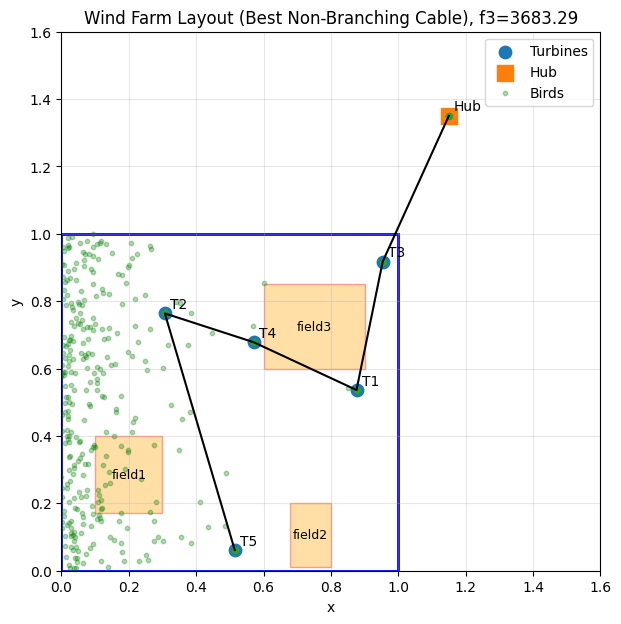

In [11]:
## inputs
hub = [1.15, 1.35]   # cables connecting order and the coordinate of the hub

# coordinates of the turbines
x = [0.87601546, 0.30708387, 0.95377465, 0.57068488, 0.51457379, 
     0.53644864, 0.76385136, 0.91770092, 0.67833953, 0.06152623]

# f1: Annual Energy Production, f2: the percetage of the birds getting too close, f3:the length of the cables
# g1: constaint 1 = 2 * self.rotor_diameter - min_dist * self.farm_length <= 0
# g2: constaint 2 = n_inside <= 0
print(problem.evaluate(x, hub)) 
problem.plot_layout(x, hub)